# Notebook 03: Model Baselines
Training and evaluating baseline models (Logistic Regression & Random Forest)

## Cell 1 — Imports

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from src.data.data_loader import (
    load_config,
    load_dataset,
    sample_dataset
)
from src.data.preprocessing import (
    basic_preprocessing_pipeline
)
from src.features.feature_engineering import (
    feature_engineering_pipeline
)
from src.features.encoder import (
    encode_categorical_columns
)
from src.models.train_test_split import (
    temporal_train_test_split,
    split_features_target
)
from src.models.smote_pipeline import (
    apply_smote
)
from src.models.baseline_models import (
    train_logistic_regression,
    train_random_forest,
    generate_predictions
)
from src.evaluation.metrics import (
    evaluate_model,
    plot_confusion_matrix
)

## Cell 2 — Load Config

In [2]:
config = load_config()

## Cell 3 — Load Dataset

In [3]:
df = load_dataset(config)
df = sample_dataset(df, config)
df.shape


Loading dataset from:
/Users/nurnafisfuad/Desktop/AccidentXAI/data/raw/US_Accidents_March23.csv


Dataset loaded successfully.


Sampling 100000 rows...



(100000, 24)

## Cell 4 — Preprocessing

In [4]:
df = basic_preprocessing_pipeline(df)
df = feature_engineering_pipeline(df)


Starting preprocessing pipeline...

Converting Start_Time to datetime format...
Removed 85 duplicate rows.

Selected relevant columns.

Dropping high-missing columns:

[]

Missing values handled successfully.

Preprocessing completed successfully.


Starting feature engineering pipeline...

Creating temporal features...

Creating rush-hour feature...

Creating night-driving feature...

Simplifying target variable...


Feature engineering completed.



## Cell 5 — Temporal Split

In [5]:
train_df, test_df = temporal_train_test_split(
    df
)


Performing temporal split...

Train Shape: (71919, 30)
Test Shape: (16318, 30)


## Cell 6 — Feature/Target Split

In [6]:
X_train, X_test, y_train, y_test = split_features_target(
    train_df,
    test_df
)


Separating features and target...

X_train shape: (71919, 29)
X_test shape: (16318, 29)


## Cell 7 — Encoding

In [7]:
X_train, X_test, encoders = encode_categorical_columns(
    X_train,
    X_test
)


Encoding categorical columns...

Encoding completed.



## Cell 8 — SMOTE

In [8]:
X_train_smote, y_train_smote = apply_smote(
    X_train,
    y_train
)


Applying SMOTE...

Before SMOTE:

Counter({0: 54138, 1: 17781})

After SMOTE:

Counter({0: 54138, 1: 54138})


## Cell 9 — Logistic Regression Training

In [9]:
logistic_model = train_logistic_regression(
    X_train_smote,
    y_train_smote
)


Training Logistic Regression...

Logistic Regression training completed.



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Cell 10 — Logistic Predictions

In [10]:
logistic_preds, logistic_probs = generate_predictions(
    logistic_model,
    X_test
)

## Cell 11 — Logistic Evaluation

In [11]:
evaluate_model(
    y_test,
    logistic_preds,
    logistic_probs,
    model_name="Logistic Regression"
)

Logistic Regression Evaluation

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.60      0.72     14872
           1       0.10      0.45      0.16      1446

    accuracy                           0.58     16318
   macro avg       0.51      0.52      0.44     16318
weighted avg       0.85      0.58      0.67     16318


ROC-AUC Score: 0.5486


## Cell 12 — Logistic Confusion Matrix

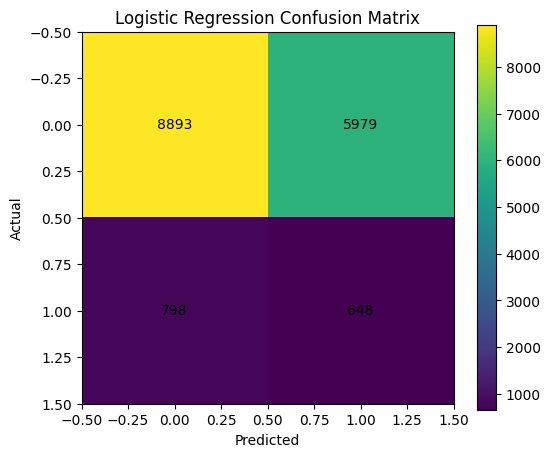

In [12]:
plot_confusion_matrix(
    y_test,
    logistic_preds,
    model_name="Logistic Regression"
)

## Cell 13 — Random Forest Training

In [13]:
rf_model = train_random_forest(
    X_train_smote,
    y_train_smote
)


Training Random Forest...

Random Forest training completed.



## Cell 14 — Random Forest Predictions

In [14]:
rf_preds, rf_probs = generate_predictions(
    rf_model,
    X_test
)

## Cell 15 — Random Forest Evaluation

In [15]:
evaluate_model(
    y_test,
    rf_preds,
    rf_probs,
    model_name="Random Forest"
)

Random Forest Evaluation

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     14872
           1       0.33      0.05      0.08      1446

    accuracy                           0.91     16318
   macro avg       0.62      0.52      0.52     16318
weighted avg       0.86      0.91      0.87     16318


ROC-AUC Score: 0.6762


## Cell 16 — Random Forest Confusion Matrix

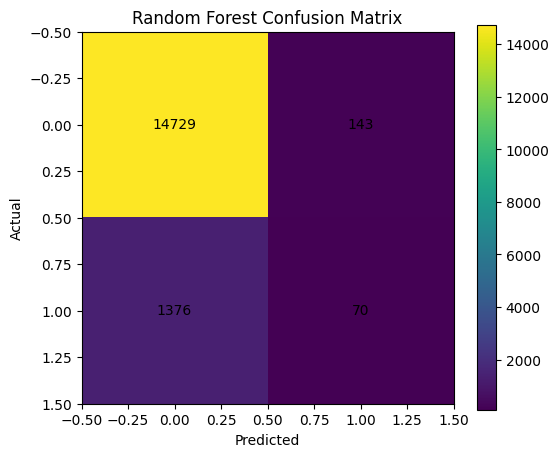

In [16]:
plot_confusion_matrix(
    y_test,
    rf_preds,
    model_name="Random Forest"
)